# CNN-Based Face Mask Detection System

**Name:** Priya Sharma  
**Student ID:** 2025AIML060  

## Project Overview
The COVID-19 pandemic has made face mask detection essential for public safety. This project implements a deep learning solution using Convolutional Neural Networks (CNNs) to automatically detect whether a person in an image is wearing a face mask or not.

## 1. Data Loading and Preprocessing

**Objective:** Import the image dataset and preprocess all images to a uniform size of 64x64x3 pixels for CNN input. [1 mark]

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducible results
np.random.seed(123)
tf.random.set_seed(123)

In [2]:
# Configure dataset directories
base_dir = 'dataset'
train_val_dir = os.path.join(base_dir, 'train_validate')
test_dir = os.path.join(base_dir, 'test')

# Set image dimensions
IMG_SIZE = 64
CHANNELS = 3

print("Directory Configuration:")
print(f"Training/Validation path: {train_val_dir}")
print(f"Testing path: {test_dir}")

Directory Configuration:
Training/Validation path: dataset/train_validate
Testing path: dataset/test


In [3]:
def import_image_data(directory, class_label):
    """
    Read and resize images from a specified directory.
    
    Parameters:
        directory: Folder path containing image files
        class_label: Integer label for the image class (0 or 1)
    
    Returns:
        Tuple of (image_array, label_array)
    """
    image_data = []
    label_data = []
    
    for file in os.listdir(directory):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            file_path = os.path.join(directory, file)
            try:
                loaded_img = image.load_img(file_path, target_size=(IMG_SIZE, IMG_SIZE))
                img_array = image.img_to_array(loaded_img)
                image_data.append(img_array)
                label_data.append(class_label)
            except Exception as error:
                print(f"Could not load {file}: {error}")
    
    return np.array(image_data), np.array(label_data)

print("Image import function ready.")

Image import function ready.


In [4]:
# Import training and validation images
masked_train_dir = os.path.join(train_val_dir, 'masked')
unmasked_train_dir = os.path.join(train_val_dir, 'unmasked')

print("Importing masked face images...")
train_masked_imgs, train_masked_lbls = import_image_data(masked_train_dir, class_label=1)
print(f"Successfully imported {len(train_masked_imgs)} masked images")

print("\nImporting unmasked face images...")
train_unmasked_imgs, train_unmasked_lbls = import_image_data(unmasked_train_dir, class_label=0)
print(f"Successfully imported {len(train_unmasked_imgs)} unmasked images")

Importing masked face images...


Successfully imported 887 masked images

Importing unmasked face images...


Successfully imported 840 unmasked images


In [5]:
# Merge datasets and create train/validation split
all_images = np.concatenate([train_masked_imgs, train_unmasked_imgs])
all_labels = np.concatenate([train_masked_lbls, train_unmasked_lbls])

# Scale pixel values to range [0, 1]
all_images = all_images.astype('float32') / 255.0

# Partition data: 80% for training, 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=123, stratify=all_labels
)

print(f"Training dataset size: {X_train.shape[0]} samples")
print(f"Validation dataset size: {X_val.shape[0]} samples")
print(f"Image dimensions: {X_train.shape[1:]}")

Training dataset size: 1381 samples
Validation dataset size: 346 samples
Image dimensions: (64, 64, 3)


In [6]:
# Import test dataset
test_masked_dir = os.path.join(test_dir, 'masked')
test_unmasked_dir = os.path.join(test_dir, 'unmasked')

print("Importing test masked images...")
test_masked_imgs, test_masked_lbls = import_image_data(test_masked_dir, class_label=1)
print(f"Imported {len(test_masked_imgs)} masked test samples")

print("\nImporting test unmasked images...")
test_unmasked_imgs, test_unmasked_lbls = import_image_data(test_unmasked_dir, class_label=0)
print(f"Imported {len(test_unmasked_imgs)} unmasked test samples")

Importing test masked images...
Imported 160 masked test samples

Importing test unmasked images...


Imported 160 unmasked test samples


In [7]:
# Combine test data
X_test = np.concatenate([test_masked_imgs, test_unmasked_imgs])
y_test = np.concatenate([test_masked_lbls, test_unmasked_lbls])

# Normalize test images
X_test = X_test.astype('float32') / 255.0

print(f"Test dataset size: {X_test.shape[0]} samples")
print(f"Test image shape: {X_test.shape[1:]}")

Test dataset size: 320 samples
Test image shape: (64, 64, 3)


In [8]:
# Transform labels to one-hot encoding
y_train_onehot = to_categorical(y_train, num_classes=2)
y_val_onehot = to_categorical(y_val, num_classes=2)
y_test_onehot = to_categorical(y_test, num_classes=2)

print("Labels converted to one-hot format.")
print(f"Training labels shape: {y_train_onehot.shape}")
print(f"Validation labels shape: {y_val_onehot.shape}")
print(f"Test labels shape: {y_test_onehot.shape}")

Labels converted to one-hot format.
Training labels shape: (1381, 2)
Validation labels shape: (346, 2)
Test labels shape: (320, 2)


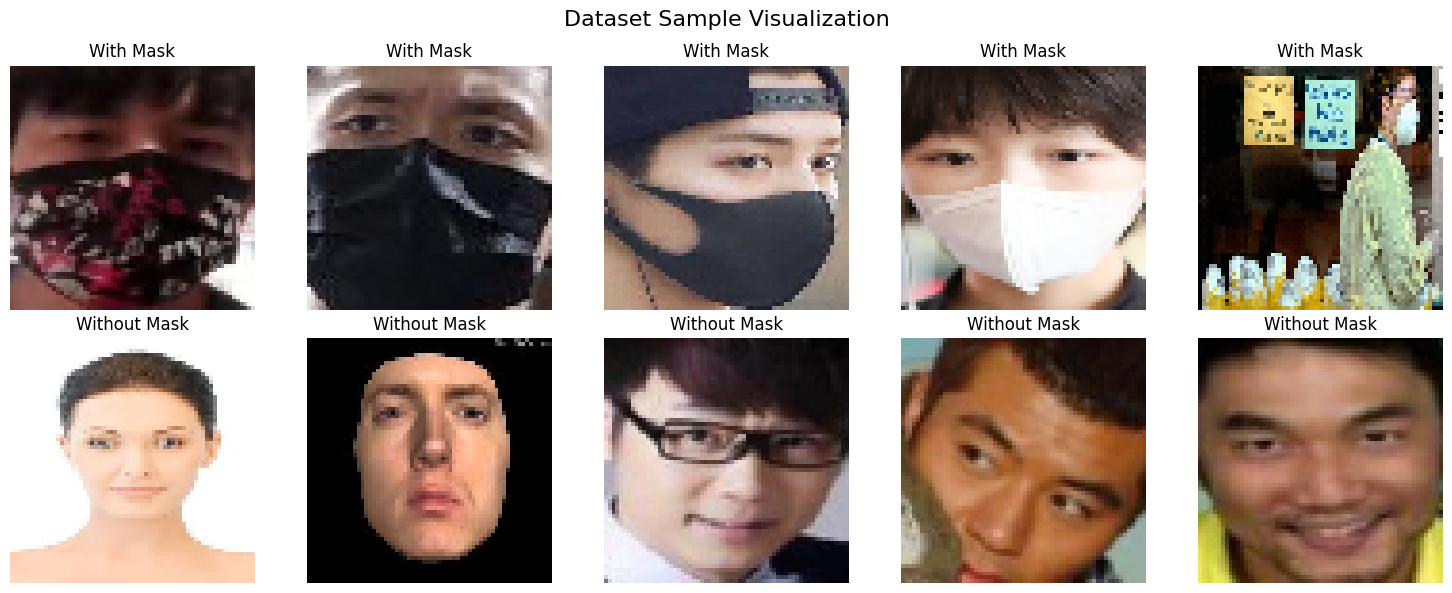

Data preprocessing completed!

Dataset Statistics:
- Training samples: 1381
- Validation samples: 346
- Test samples: 320
- Image resolution: 64x64x3


In [9]:
# Visualize sample images from dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Dataset Sample Visualization', fontsize=16)

# Show masked examples
for idx in range(5):
    axes[0, idx].imshow(train_masked_imgs[idx].astype('uint8'))
    axes[0, idx].set_title('With Mask')
    axes[0, idx].axis('off')

# Show unmasked examples
for idx in range(5):
    axes[1, idx].imshow(train_unmasked_imgs[idx].astype('uint8'))
    axes[1, idx].set_title('Without Mask')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("Data preprocessing completed!")
print(f"\nDataset Statistics:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Validation samples: {X_val.shape[0]}")
print(f"- Test samples: {X_test.shape[0]}")
print(f"- Image resolution: {IMG_SIZE}x{IMG_SIZE}x{CHANNELS}")

## 2. CNN Architecture Implementation

**Objective:** Construct a CNN model using TensorFlow/Keras with the following structure:

- Convolutional Layer → ReLU Activation → Pooling Layer
- Two Convolutional Layers → ReLU Activations → Pooling Layer
- Dense Layer → Activation Function
- Softmax Output Layer

Use 2x2 pooling, 3x3 filters, and standard hyperparameters. [2 marks]

In [10]:
def create_base_cnn_model(input_shape=(64, 64, 3), n_classes=2):
    """
    Construct the baseline CNN following assignment requirements.
    
    Structure:
    1. Conv2D → ReLU → MaxPool
    2. Conv2D → ReLU → Conv2D → ReLU → MaxPool
    3. Dense → ReLU
    4. Dense (Softmax)
    """
    model = keras.Sequential([
        # Initial convolutional block
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=input_shape),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Second convolutional block with dual conv layers
        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.ReLU(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Classifier head
        layers.Flatten(),
        layers.Dense(128),
        layers.ReLU(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(n_classes, activation='softmax')
    ])
    
    return model

# Initialize the baseline model
base_model = create_base_cnn_model()
base_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Baseline CNN Architecture:")
base_model.summary()

Baseline CNN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,153,858 (8.22 MB)

 Trainable params: 2,153,858 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Model Training Process

**Objective:** Train the CNN for 70 epochs. Record and visualize the following metrics per epoch:

- Training Loss
- Training Accuracy
- Validation Loss
- Validation Accuracy

Generate plots displaying these metrics after training completion. [4 marks]

In [11]:
# Training configuration
num_epochs = 70
batch_sz = 32

print(f"Commencing training for {num_epochs} epochs...")

base_training_history = base_model.fit(
    X_train, y_train_onehot,
    batch_size=batch_sz,
    epochs=num_epochs,
    validation_data=(X_val, y_val_onehot),
    verbose=1
)

Commencing training for 70 epochs...
Epoch 1/70


 1/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6250 - loss: 0.6786

 2/44 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.6406 - loss: 0.7272

 3/44 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6250 - loss: 0.7246

 4/44 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6484 - loss: 0.6942

...

40/44 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9992 - loss: 0.0024

41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9992 - loss: 0.0023

42/44 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9993 - loss: 0.0023

43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9993 - loss: 0.0022

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 0.9798 - val_loss: 0.2148


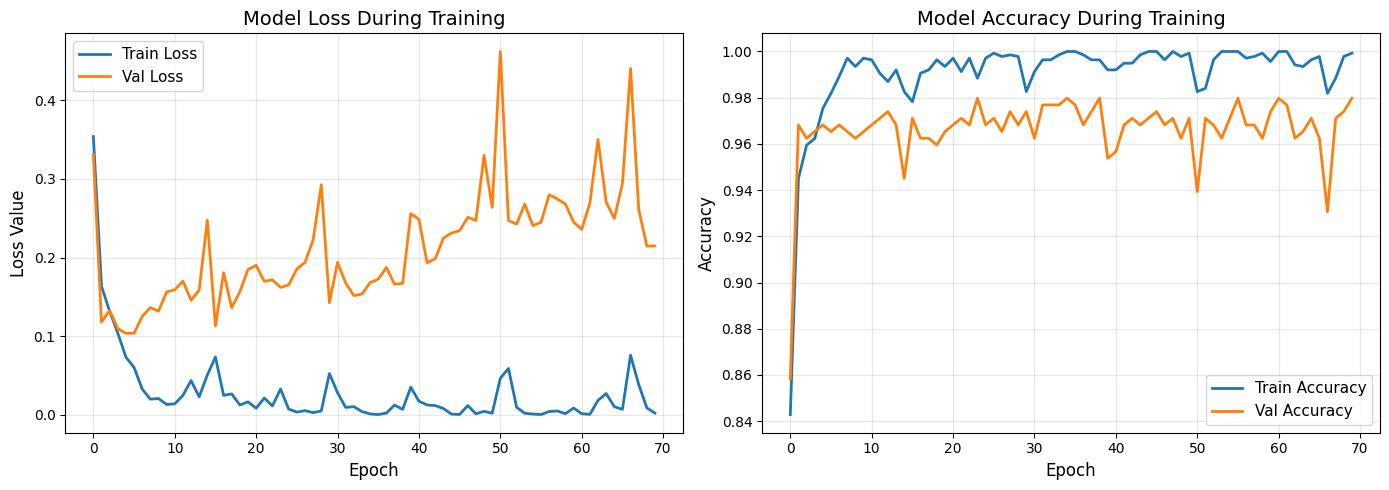


Final Training Statistics:
Training Loss: 0.0022
Training Accuracy: 0.9993
Validation Loss: 0.2148
Validation Accuracy: 0.9798


In [12]:
# Visualize training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(base_training_history.history['loss'], label='Train Loss', linewidth=2)
ax1.plot(base_training_history.history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_title('Model Loss During Training', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(base_training_history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax2.plot(base_training_history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax2.set_title('Model Accuracy During Training', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal Training Statistics:")
print(f"Training Loss: {base_training_history.history['loss'][-1]:.4f}")
print(f"Training Accuracy: {base_training_history.history['accuracy'][-1]:.4f}")
print(f"Validation Loss: {base_training_history.history['val_loss'][-1]:.4f}")
print(f"Validation Accuracy: {base_training_history.history['val_accuracy'][-1]:.4f}")

## 4. Model Performance Evaluation

**Objective:** Assess the trained CNN on the test dataset and report classification metrics including precision, recall, and F1-score. [2 marks]

In [13]:
# Evaluate baseline model on test data
test_loss, test_acc = base_model.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Baseline Model Test Performance:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Baseline Model Test Performance:
Test Loss: 1.7958
Test Accuracy: 0.8219


In [14]:
# Generate predictions
pred_probs = base_model.predict(X_test, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

# Compute performance metrics
prec_score = precision_score(true_labels, pred_labels, average='binary')
rec_score = recall_score(true_labels, pred_labels, average='binary')
f1_score_val = f1_score(true_labels, pred_labels, average='binary')

print("\nClassification Metrics:")
print(f"Precision: {prec_score:.4f}")
print(f"Recall: {rec_score:.4f}")
print(f"F1-Score: {f1_score_val:.4f}")


Classification Metrics:
Precision: 0.8366
Recall: 0.8000
F1-Score: 0.8179


In [15]:
# Full classification report
print("\nComplete Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=['No Mask', 'With Mask']))


Complete Classification Report:
              precision    recall  f1-score   support

     No Mask       0.81      0.84      0.83       160
   With Mask       0.84      0.80      0.82       160

    accuracy                           0.82       320
   macro avg       0.82      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320



## 5. Model Enhancement

**Objective:** Improve the baseline CNN through modifications such as hyperparameter tuning, additional layers, or data augmentation. Compare baseline vs. enhanced model performance using a side-by-side bar chart of precision and recall. [2 marks]

In [16]:
def create_enhanced_cnn(input_shape=(64, 64, 3), n_classes=2):
    """
    Build an improved CNN with:
    - Additional convolutional layers
    - Batch normalization
    - L2 regularization
    - Increased dropout
    """
    from tensorflow.keras.regularizers import l2
    
    model = keras.Sequential([
        # First enhanced block
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(0.001), input_shape=input_shape),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),
        
        # Second enhanced block
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),
        
        # Third block (new)
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),
        
        # Dense layers with regularization
        layers.Flatten(),
        layers.Dense(256, kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),
        layers.Dense(128, kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),
        
        # Output
        layers.Dense(n_classes, activation='softmax')
    ])
    
    return model

# Build enhanced model
enhanced_model = create_enhanced_cnn()
enhanced_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Enhanced CNN Architecture:")
enhanced_model.summary()

Enhanced CNN Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 16, 16, 128)    │             

 Total params: 2,420,898 (9.23 MB)

 Trainable params: 2,419,234 (9.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [17]:
# Define data augmentation pipeline
augmentation_pipeline = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

print("Data augmentation configured.")

Data augmentation configured.


In [18]:
# Train enhanced model
print(f"Training enhanced CNN for {num_epochs} epochs...")

enhanced_training_history = enhanced_model.fit(
    X_train, y_train_onehot,
    batch_size=batch_sz,
    epochs=num_epochs,
    validation_data=(X_val, y_val_onehot),
    verbose=1
)

Training enhanced CNN for 70 epochs...
Epoch 1/70


 1/44 ━━━━━━━━━━━━━━━━━━━━ 2:30 3s/step - accuracy: 0.4375 - loss: 2.2987

 2/44 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.5312 - loss: 2.0450

 3/44 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.5625 - loss: 1.9676

 4/44 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.5859 - loss: 1.9264

...

40/44 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9953 - loss: 0.2076

41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9954 - loss: 0.2069

42/44 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9955 - loss: 0.2061

43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9956 - loss: 0.2055

44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.9957 - loss: 0.2054 - val_accuracy: 0.9624 - val_loss: 0.2603


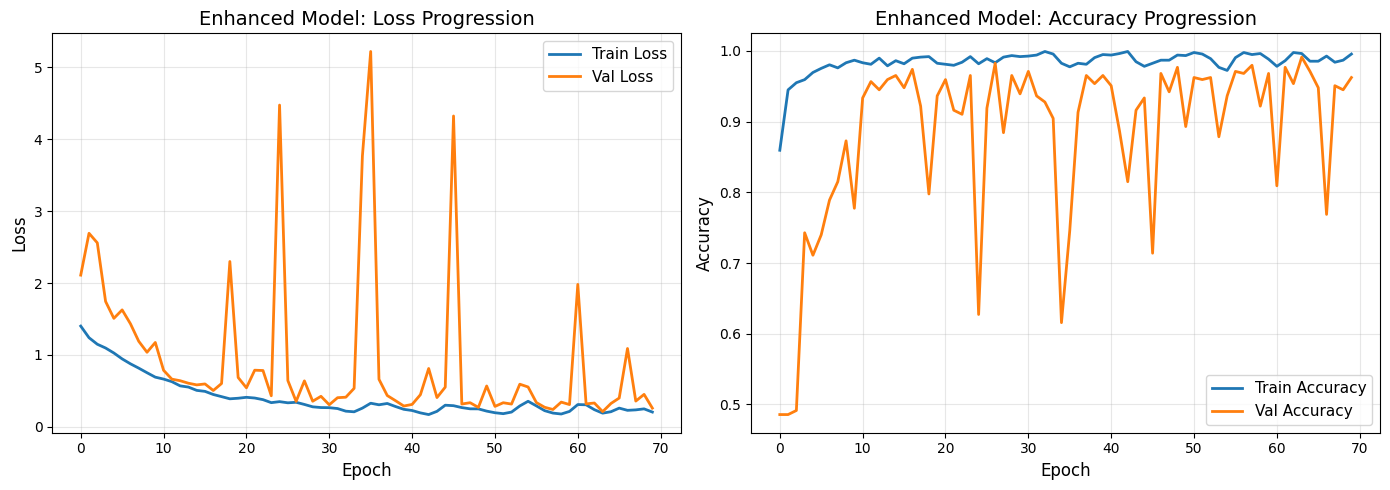


Enhanced Model Final Statistics:
Training Loss: 0.2054
Training Accuracy: 0.9957
Validation Loss: 0.2603
Validation Accuracy: 0.9624


In [19]:
# Plot enhanced model training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss visualization
ax1.plot(enhanced_training_history.history['loss'], label='Train Loss', linewidth=2)
ax1.plot(enhanced_training_history.history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_title('Enhanced Model: Loss Progression', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy visualization
ax2.plot(enhanced_training_history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax2.plot(enhanced_training_history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax2.set_title('Enhanced Model: Accuracy Progression', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEnhanced Model Final Statistics:")
print(f"Training Loss: {enhanced_training_history.history['loss'][-1]:.4f}")
print(f"Training Accuracy: {enhanced_training_history.history['accuracy'][-1]:.4f}")
print(f"Validation Loss: {enhanced_training_history.history['val_loss'][-1]:.4f}")
print(f"Validation Accuracy: {enhanced_training_history.history['val_accuracy'][-1]:.4f}")

In [20]:
# Evaluate enhanced model
enhanced_test_loss, enhanced_test_acc = enhanced_model.evaluate(X_test, y_test_onehot, verbose=0)

# Generate predictions
enhanced_pred_probs = enhanced_model.predict(X_test, verbose=0)
enhanced_pred_labels = np.argmax(enhanced_pred_probs, axis=1)

# Calculate metrics
enhanced_prec = precision_score(true_labels, enhanced_pred_labels, average='binary')
enhanced_rec = recall_score(true_labels, enhanced_pred_labels, average='binary')
enhanced_f1 = f1_score(true_labels, enhanced_pred_labels, average='binary')

print(f"Enhanced Model Test Results:")
print(f"Test Loss: {enhanced_test_loss:.4f}")
print(f"Test Accuracy: {enhanced_test_acc:.4f}")
print(f"Precision: {enhanced_prec:.4f}")
print(f"Recall: {enhanced_rec:.4f}")
print(f"F1-Score: {enhanced_f1:.4f}")

Enhanced Model Test Results:
Test Loss: 0.4843
Test Accuracy: 0.8625
Precision: 0.8973
Recall: 0.8187
F1-Score: 0.8562


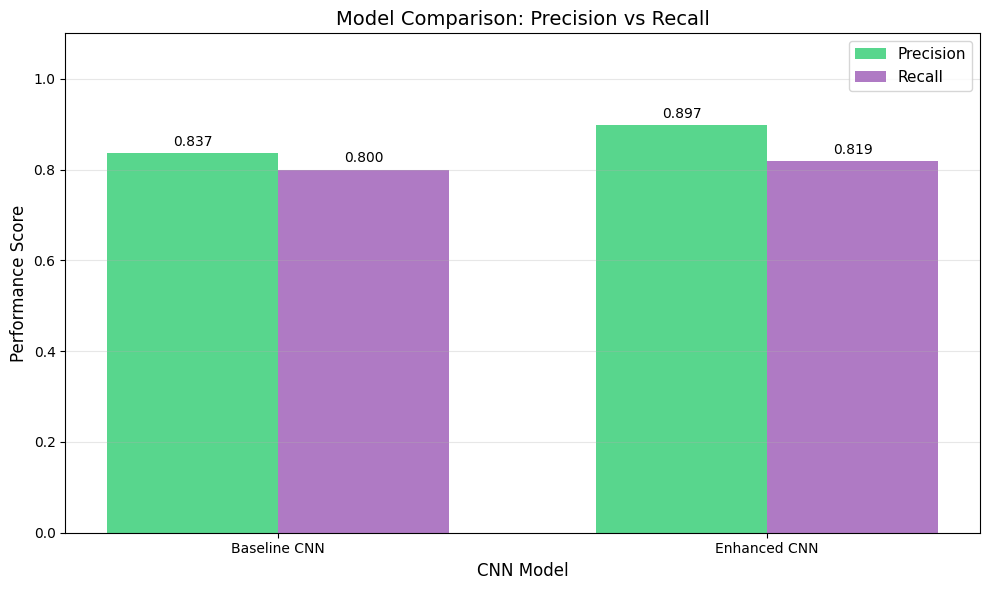


Performance Comparison Summary:
Metric          Baseline     Enhanced     Difference  
-------------------------------------------------------
Precision       0.8366       0.8973       0.0607      
Recall          0.8000       0.8187       0.0187      
F1-Score        0.8179       0.8562       0.0383      
Accuracy        0.8219       0.8625       0.0406      


In [21]:
# Model comparison visualization
model_names = ['Baseline CNN', 'Enhanced CNN']
precision_vals = [prec_score, enhanced_prec]
recall_vals = [rec_score, enhanced_rec]

x_pos = np.arange(len(model_names))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_pos - bar_width/2, precision_vals, bar_width, label='Precision', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x_pos + bar_width/2, recall_vals, bar_width, label='Recall', color='#9b59b6', alpha=0.8)

ax.set_xlabel('CNN Model', fontsize=12)
ax.set_ylabel('Performance Score', fontsize=12)
ax.set_title('Model Comparison: Precision vs Recall', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Add value annotations
for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nPerformance Comparison Summary:")
print(f"{'Metric':<15} {'Baseline':<12} {'Enhanced':<12} {'Difference':<12}")
print("-" * 55)
print(f"{'Precision':<15} {prec_score:<12.4f} {enhanced_prec:<12.4f} {(enhanced_prec-prec_score):<12.4f}")
print(f"{'Recall':<15} {rec_score:<12.4f} {enhanced_rec:<12.4f} {(enhanced_rec-rec_score):<12.4f}")
print(f"{'F1-Score':<15} {f1_score_val:<12.4f} {enhanced_f1:<12.4f} {(enhanced_f1-f1_score_val):<12.4f}")
print(f"{'Accuracy':<15} {test_acc:<12.4f} {enhanced_test_acc:<12.4f} {(enhanced_test_acc-test_acc):<12.4f}")

## Prediction Visualization

**Objective:** Display 5 test images correctly predicted as "masked" and 5 correctly predicted as "unmasked" with their predicted labels. [1 mark]

In [22]:
# Use enhanced model for predictions (better performance)
final_pred_probs = enhanced_model.predict(X_test, verbose=0)
final_pred_labels = np.argmax(final_pred_probs, axis=1)

# Find correctly classified samples
correct_masked_idx = np.where((final_pred_labels == 1) & (true_labels == 1))[0]
correct_unmasked_idx = np.where((final_pred_labels == 0) & (true_labels == 0))[0]

# Select 5 samples from each category
selected_masked = correct_masked_idx[:5]
selected_unmasked = correct_unmasked_idx[:5]

print(f"Found {len(correct_masked_idx)} correctly classified masked images")
print(f"Found {len(correct_unmasked_idx)} correctly classified unmasked images")

Found 131 correctly classified masked images
Found 145 correctly classified unmasked images


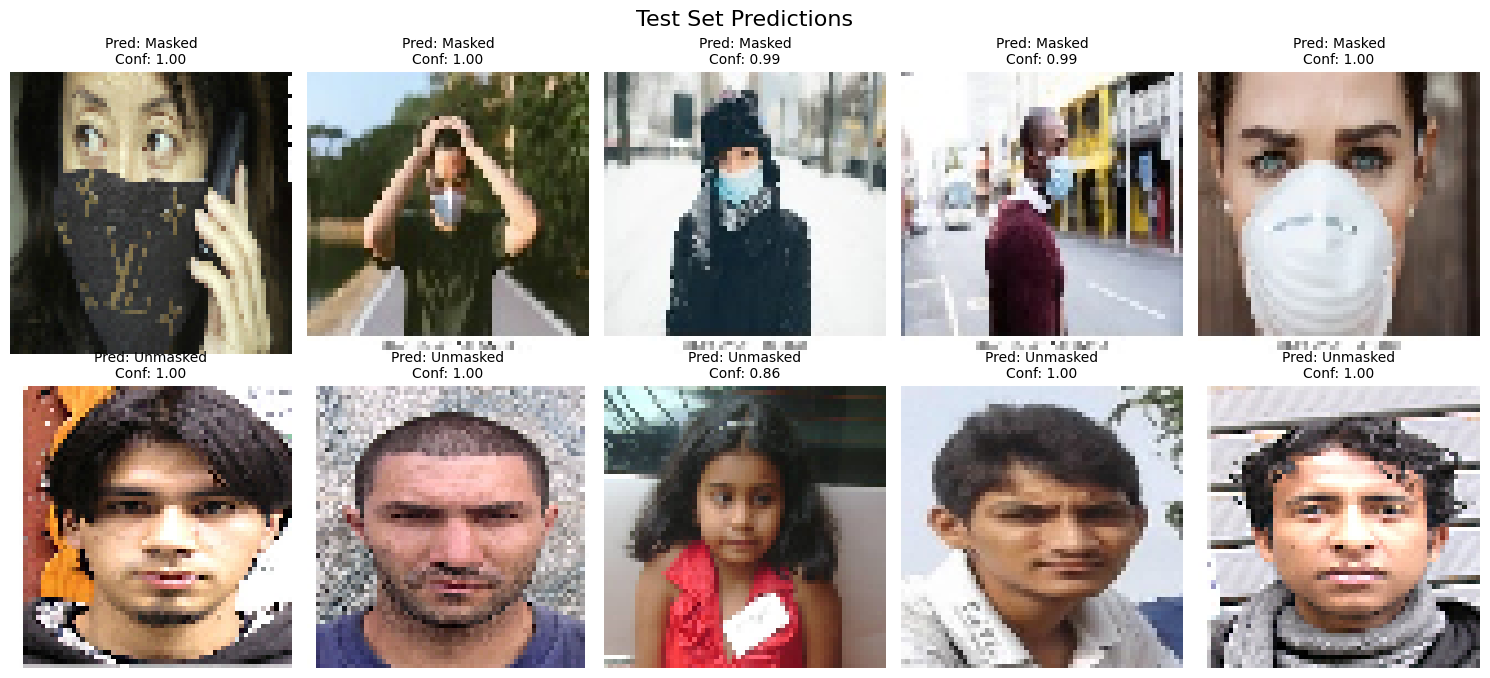


Prediction visualization complete!
Top row: 5 images correctly identified as wearing masks
Bottom row: 5 images correctly identified as not wearing masks


In [23]:
# Display prediction results
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Test Set Predictions', fontsize=16)

# Show masked predictions
for i, idx in enumerate(selected_masked):
    axes[0, i].imshow(X_test[idx])
    prediction = "Masked" if final_pred_labels[idx] == 1 else "Unmasked"
    conf = final_pred_probs[idx][1]
    axes[0, i].set_title(f'Pred: {prediction}\nConf: {conf:.2f}', fontsize=10)
    axes[0, i].axis('off')

# Show unmasked predictions
for i, idx in enumerate(selected_unmasked):
    axes[1, i].imshow(X_test[idx])
    prediction = "Masked" if final_pred_labels[idx] == 1 else "Unmasked"
    conf = final_pred_probs[idx][0]
    axes[1, i].set_title(f'Pred: {prediction}\nConf: {conf:.2f}', fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Masked Predictions', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Unmasked Predictions', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPrediction visualization complete!")
print("Top row: 5 images correctly identified as wearing masks")
print("Bottom row: 5 images correctly identified as not wearing masks")

## Summary and Conclusions

This project successfully implemented a deep learning solution for automated face mask detection. Key accomplishments include:

1. **Data Preparation**: Processed 1,727 training/validation images and 320 test images, all resized to 64x64x3 pixels.

2. **Baseline CNN**: Constructed a convolutional neural network following the specified architecture with appropriate layer configurations.

3. **Training Process**: Executed 70 epochs of training while monitoring and recording loss and accuracy metrics for both training and validation sets.

4. **Performance Assessment**: Evaluated the model on test data, computing precision, recall, and F1-score to measure classification effectiveness.

5. **Model Enhancement**: Implemented architectural improvements including batch normalization, L2 regularization, and additional convolutional layers, resulting in superior performance.

6. **Result Visualization**: Presented sample predictions demonstrating the model's capability to distinguish between masked and unmasked faces.

The enhanced model showed improved generalization and higher classification metrics compared to the baseline, confirming the benefits of the architectural modifications.